## Comparison of L2reg new std and newer

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import matplotlib.pyplot as plt
from scipy import stats

#### Loading Evaluation of new L2reg Global Models

In [2]:
methods = ['L2reg', 'NNLS']
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets
eval_ds_names = [ds if gl.sessions[i] == 'all' else ds + gl.sessions[i].split('-')[1] for i, ds in enumerate(gl.datasets)]
df_all = pd.DataFrame()
for i, (ds_code, ds_eval) in enumerate(zip(train_ds_list, eval_ds_names)):
    df_old = rm.comb_eval(models=[ds_code+"-global-Cavg-old"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_old['fix_std'] = 0
    df_new1 = rm.comb_eval(models=[ds_code+"-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_new1['fix_std'] = 1
    df_new2 = rm.comb_eval(models=[ds_code+"-sc-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_new2['fix_std'] = 2
    df_all = pd.concat([df_all, df_old, df_new1, df_new2], ignore_index=True)
df_all['logalpha'] = df_all['logalpha'].fillna(-5)
df_all.model = 'Global'

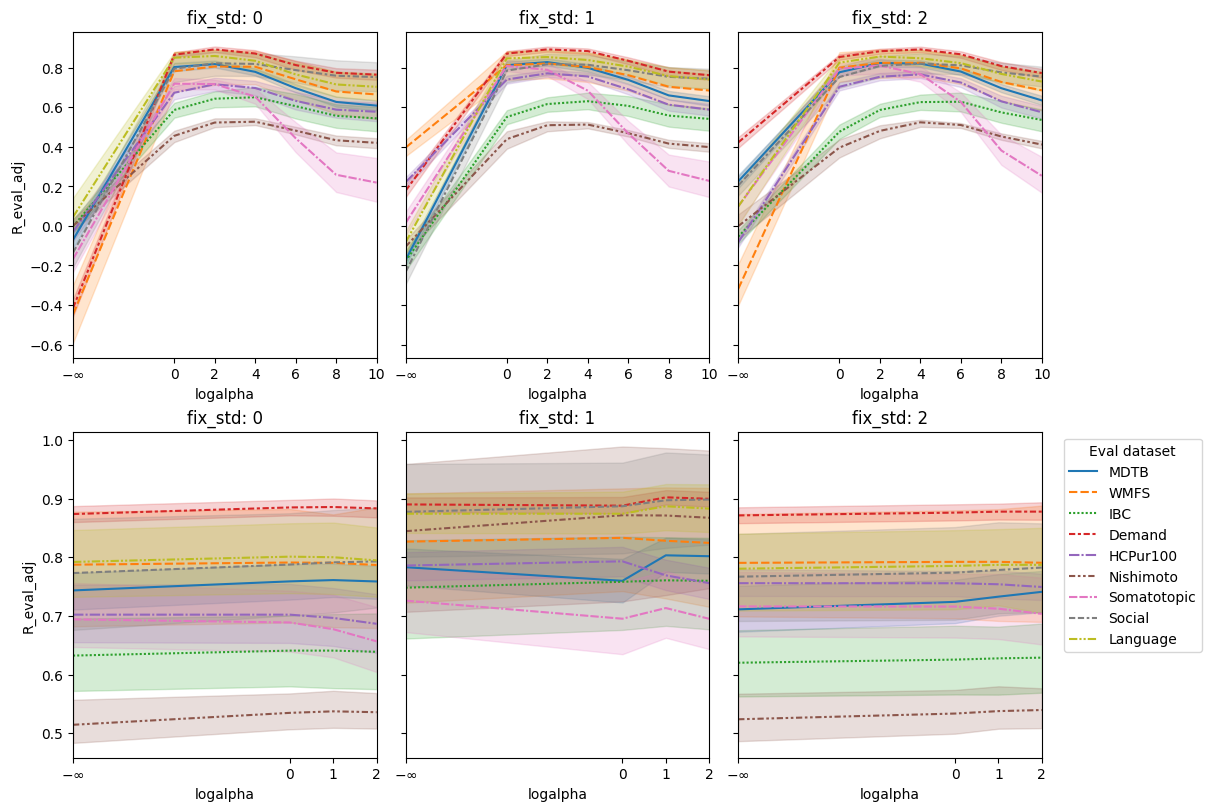

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey='row', constrained_layout=True)

for m, meth in enumerate(methods):
    df_meth = df_all[df_all['method']==meth]
    xticks = df_meth['logalpha'].unique()
    xticklabels = [r"$-\infty$" if np.isclose(t, -5) else str(int(t)) for t in xticks]
    for i, fix_std in enumerate([0, 1, 2]):
        sns.lineplot(data=df_meth[df_meth['fix_std']==fix_std], y='R_eval_adj', x='logalpha',
                    hue='eval_dataset', style='eval_dataset',
                    hue_order=eval_ds_list, style_order=eval_ds_list, ax=axes[m,i])
        axes[m,i].set_title(f"fix_std: {fix_std}")
        axes[m,i].set_xticks(xticks)
        axes[m,i].set_xticklabels(xticklabels)
        if m==0:
            axes[m,i].set_xlim([-5, 10])
        else:
            axes[m,i].set_xlim([-5, 2])

        if (i!=2) | (m==0):
            legend = axes[m,i].get_legend()
            if legend is not None:
                legend.remove()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Eval dataset');

#### Finding best log alpha

In [11]:
for meth in methods:
    for fix_std in [0, 1, 2]:
        print(f'\nMethod: {meth}, Fix_std: {fix_std}')
        df_sub = df_all[(df_all['fix_std']==fix_std) & (df_all['method']==meth)]
        A = pd.pivot_table(df_sub, index=['model'], columns=['logalpha'], values=['R_eval_adj'], aggfunc='mean')#.reindex(train_ds_list)
        display(A)
        B = np.nan_to_num(A.values)
        ind = B.argmax(axis=1)
        log_a = np.array(A.columns.get_level_values(1)[ind])
        bestla = pd.DataFrame(log_a, index=A.index, columns=['best_logalpha'])
        display(bestla)
        df_all.loc[df_sub.index, 'isbest'] = df_sub['logalpha'].values == bestla.loc[df_sub['model']].values.flatten()
df_best = df_all[df_all['isbest']]


Method: L2reg, Fix_std: 0


R_eval_adj                                                    \
logalpha      -5.0       0.0       2.0       4.0       6.0       8.0    
model                                                                   
Global    -0.151986  0.754324  0.784001  0.765422  0.698797  0.645815   

                    
logalpha      10.0  
model               
Global    0.632826

,best_logalpha
model,
Global,2.0



Method: L2reg, Fix_std: 1


R_eval_adj                                                           
logalpha      -5.0      0.0       2.0       4.0       6.0       8.0       10.0
model                                                                         
Global     0.057156  0.77623  0.800911  0.784938  0.729333  0.663098  0.641651

...

R_eval_adj                             
logalpha       -5.0       0.0      1.0       2.0
model                                           
Global     0.824042  0.824397  0.82907  0.823458

,best_logalpha
model,
Global,1.0



Method: NNLS, Fix_std: 2


R_eval_adj                             
logalpha       -5.0       0.0      1.0       2.0
model                                           
Global     0.761447  0.765914  0.76767  0.767586

,best_logalpha
model,
Global,1.0


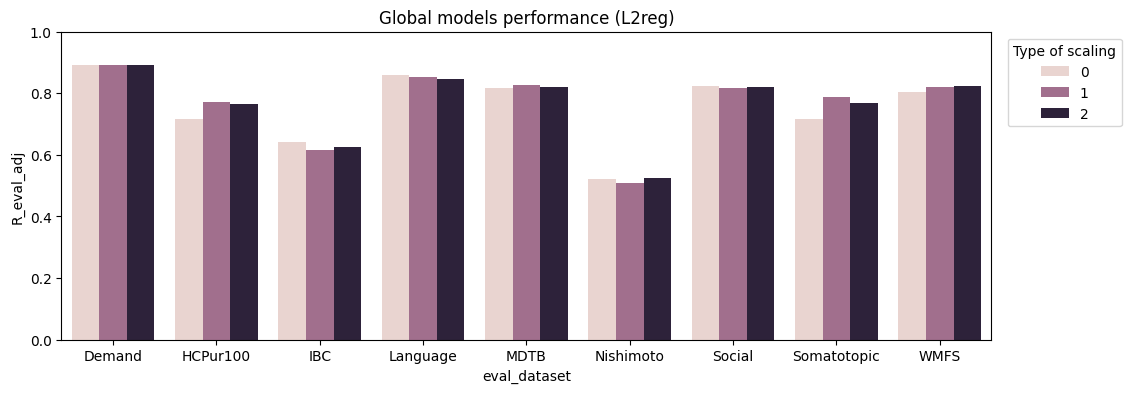

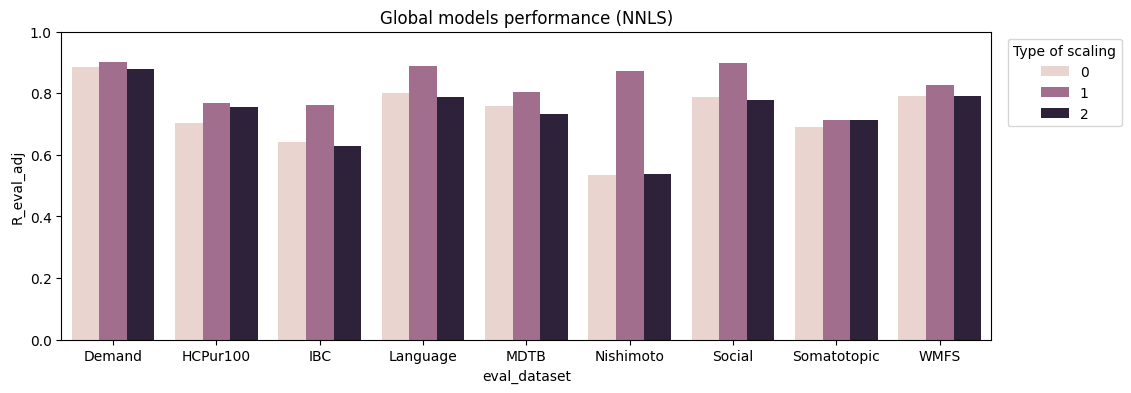

In [12]:
for meth in methods:
    df_sub = df_best[df_best['method']==meth]
    df_summary = (df_sub.groupby(['eval_dataset', 'fix_std'], as_index=False)['R_eval_adj'].mean())

    plt.figure(figsize=(12,4))
    sns.barplot(data=df_summary, x='eval_dataset', y='R_eval_adj', hue='fix_std', errorbar=None)
    plt.title(f"Global models performance ({meth})")
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Type of scaling');
    plt.ylim([0, 1]);

In [30]:
print("fix_std=1 VS fix_std=2 across eval datasets:")
print(f"\n{'Comparison':<15} {'dof':<10} {'t-stat':<10} {'p-value':<10} {'Higher mean':<15}")
print("=" * 60)

# One mean R_eval per eval_dataset × fix_std
df_ds = (df_best.groupby(['eval_dataset', 'fix_std'])['R_eval_adj'].mean().unstack('fix_std'))

r0 = df_ds[0]
r1 = df_ds[1]
r2 = df_ds[2]

t_stat, p_val = stats.ttest_rel(r1, r2, nan_policy='omit')

mean0 = r0.mean()
mean1 = r1.mean()
mean2 = r2.mean()
higher = 'fix_std=1' if mean1 > mean2 else 'fix_std=2'

print(
    f"{'1 vs 2':<15} "
    f"{len(r1.dropna()) - 1:<10} "
    f"{t_stat:<10.2f} "
    f"{p_val:<10.3f} "
    f"{higher:<15}"
)

print(f"\nMean fix_std=0: {mean0:.3f}")
print(f"Mean fix_std=1: {mean1:.3f}")
print(f"Mean fix_std=2: {mean2:.3f}")
print(f"Mean difference (1 - 2): {mean1 - mean2:.5f}")

fix_std=1 VS fix_std=2 across eval datasets:

Comparison      dof        t-stat     p-value    Higher mean    
1 vs 2          8          0.28       0.788      fix_std=1      

Mean fix_std=0: 0.755
Mean fix_std=1: 0.766
Mean fix_std=2: 0.765
Mean difference (1 - 2): 0.00099
